# Toy model: an unknown number of spins on ten sites

`toy_three_spins_ten_sites` told the sampler there were three spins. Here it
is not told. The same ten sites and the same three true spins are used, but
the walk starts with a single spin and has to find out how many there are.
That needs a third kind of move, so the schedule now cycles three blocks:

| block | move | what it changes |
|---|---|---|
| **RJMCMC** | birth or death of one spin | the number of spins |
| **site walk** | one spin hops to an unoccupied site | which sites are occupied |
| **offset walk** | one component of one spin's offset takes a step | the couplings |

The relaxation rules are those of the previous notebook. Each component of a
site's coupling may move ±10% of its own table value, with a flat prior, so
the rectangle is as large as the site is strongly coupled. Each site
remembers its own offset: a spin that lands on a site, by a hop or by a
birth, resumes from where that site was last left, or from the table value
if it has never been occupied.

The prior on the number of spins is uniform from zero to six.

As before, this is the package's site memory, switched on with
`site_memory=True`. Without it a hop carries the offset with the spin, and a
newborn spin starts at its table value.

In [1]:
import collections
import sys
from pathlib import Path

import matplotlib.pyplot as plt
import numpy as np
from matplotlib.patches import Patch, Rectangle

REPO = Path.cwd().parent if Path.cwd().name == "notebooks" else Path.cwd()
if str(REPO / "src") not in sys.path:
    sys.path.insert(0, str(REPO / "src"))

from nuclear_spin_recovery import (
    RJMCMC,
    RWMH,
    AnalyticCCE1,
    BirthDeathKernel,
    DiscreteLatticeWalk,
    Envelope,
    Experiment,
    ExperimentSet,
    GaussianL2,
    HybridDriver,
    NeighborIndex,
    ParameterBlock,
    Schedule,
    SiteScaledOffset,
    SiteTable,
    State,
    Step,
    Target,
    Trace,
    gyromagnetic_ratio,
    simulate_coherence,
    simulate_dataset,
)

# One colour per algorithm, used for the stripes in section 4 and nowhere
# else.  Samples are a single colour, because spins are born and die and have
# no identity to follow; sites are labelled by number.
ALGORITHM_COLOURS = {"RJMCMC": "#2a78d6", "site walk": "#eb6834",
                     "offset walk": "#1baf7a"}
C_SAMPLE, C_RECOVERED = "#2a78d6", "#4a3aa7"
C_INK, C_MUTED, C_GRID, C_AXIS = "#0b0b0b", "#898781", "#e1e0d9", "#c3c2b7"
C_SOFT = "#f0efec"
plt.rcParams.update({
    "axes.spines.top": False, "axes.spines.right": False,
    "axes.edgecolor": C_AXIS, "axes.labelcolor": "#52514e",
    "xtick.color": C_MUTED, "ytick.color": C_MUTED,
    "grid.color": C_GRID, "grid.linewidth": 0.6, "legend.frameon": False,
    "figure.dpi": 110,
})

## 1. The lattice and the truth

The same ten sites as the previous notebook, with the same three true spins.

In [2]:
FRACTION = 0.10                        # each component may move ±10%

CENTRES = np.array([
    (100.0, 100.0),    # 0
    (10.0, 10.0),      # 1
    (100.0, 50.0),     # 2
    (60.0, 80.0),      # 3
    (150.0, 60.0),     # 4
    (40.0, 30.0),      # 5
    (75.0, 120.0),     # 6
    (130.0, 110.0),    # 7
    (25.0, 60.0),      # 8
    (55.0, 45.0),      # 9
])
N_SITES = len(CENTRES)
HALF = FRACTION * np.abs(CENTRES)      # (n_sites, 2) half-widths, kHz

# The spins the data are simulated from: site -> offset from its table value.
TRUE = {2: (5.0, 2.0), 3: (-4.0, 5.0), 7: (8.0, -6.0)}
TRUE_SITES = tuple(sorted(TRUE))
START_SITES = (0,)                     # one spin, on a site that is not true
K_MAX = 6

# Real-space positions only decide which sites are neighbours.  The ten sit on
# a ring and the walk radius reaches all of them.
_angle = np.linspace(0.0, 2.0 * np.pi, N_SITES, endpoint=False)
POSITIONS = np.column_stack([2.0 * np.cos(_angle), 2.0 * np.sin(_angle),
                             np.full(N_SITES, 2.0)])
HOP_RADIUS = 10.0

table = SiteTable(
    distance=np.linalg.norm(POSITIONS, axis=1), positions=POSITIONS,
    a_par=CENTRES[:, 0], a_perp=CENTRES[:, 1],
    isotope=np.array(["13C"] * N_SITES),
    gyro=np.full(N_SITES, gyromagnetic_ratio("13C")))

print(f"{'site':>4s} {'A_par':>7s} {'A_perp':>7s}   allowed range (kHz)")
for i in range(N_SITES):
    note = "   <- true spin, offset ({:+.0f}, {:+.0f})".format(*TRUE[i]) \
        if i in TRUE else ("   <- start" if i in START_SITES else "")
    print(f"{i:4d} {CENTRES[i, 0]:7.0f} {CENTRES[i, 1]:7.0f}   "
          f"±{HALF[i, 0]:4.1f} × ±{HALF[i, 1]:4.1f}{note}")

site   A_par  A_perp   allowed range (kHz)
   0     100     100   ±10.0 × ±10.0   <- start
   1      10      10   ± 1.0 × ± 1.0
   2     100      50   ±10.0 × ± 5.0   <- true spin, offset (+5, +2)
   3      60      80   ± 6.0 × ± 8.0   <- true spin, offset (-4, +5)
   4     150      60   ±15.0 × ± 6.0
   5      40      30   ± 4.0 × ± 3.0
   6      75     120   ± 7.5 × ±12.0
   7     130     110   ±13.0 × ±11.0   <- true spin, offset (+8, -6)
   8      25      60   ± 2.5 × ± 6.0
   9      55      45   ± 5.5 × ± 4.5


## 2. The sampler

CPMG-4 and no envelope, as in the earlier toy notebooks.

All three moves are the package's own: `RJMCMC` with a `BirthDeathKernel`,
and `RWMH` over the `sites` and `offsets` blocks. Site memory is what makes
a newborn spin take the offset its site remembers; a death needs nothing,
since the site keeps its offset when the spin is removed.

The acceptance of a birth or a death is the likelihood ratio alone. The
package's kernel is built so that the count of configurations of each size
cancels against the proposal, which leaves a prior that is uniform in the
number of spins.

In [3]:
DATA_NOISE, LIK_SIGMA = 0.002, 0.02
N_PULSES, B_Z = 4, 311.0
tau = np.linspace(3.2e-5, 8e-3, 250)   # ms
blank = ExperimentSet([Experiment(tau=tau, n_pulses=N_PULSES, b_z=B_Z)])


class NoEnvelope(Envelope):
    """No attenuation: the coherence is the spin modulation alone."""

    def __call__(self, tau, exp_id, lam, n_stretch):
        return np.ones_like(np.asarray(tau, dtype=float))


#: The label each algorithm writes to the trace, and its name in the figures.
ALGORITHM_NAMES = {
    "rjmcmc:sites": "RJMCMC",
    "rwmh:sites": "site walk",
    "rwmh:offsets": "offset walk",
}

model = AnalyticCCE1(NoEnvelope())


def make_state(sites, offsets=None):
    """Spins on ``sites``, each offset from its table value."""
    state = State.from_sites(
        tuple(int(s) for s in sites), n_sites=N_SITES, n_exp=1,
        # A State must carry a decay constant; NoEnvelope never reads it.
        lam=np.ones((1, 1)), n_stretch=np.ones((1, 1)),
        sigma=np.full((1, 1), LIK_SIGMA), k_max=K_MAX, site_memory=True)
    if offsets is not None:
        for slot, (d_par, d_perp) in enumerate(offsets):
            state.set_offset(0, slot, 0, d_par)
            state.set_offset(0, slot, 1, d_perp)
    return state


truth = make_state(TRUE_SITES, [TRUE[s] for s in TRUE_SITES])
data = simulate_dataset(truth, blank, table, model, sigma=DATA_NOISE,
                        rng=np.random.default_rng(3))
target = Target(data, model, GaussianL2(), table)

## 3. One run

A cycle is 10 RJMCMC steps, 10 site-walk steps and 40 offset steps. The
blocks are long enough to see as stripes in the next section.

With the number of spins changing, "the recovered configuration" needs a
definition. The highest-likelihood sample would favour extra spins, since
an extra parameter never makes the best fit worse. So the recovered sites
are the **most often visited set of sites** after burn-in, and the recovered
couplings are the highest-likelihood sample among the steps on that set.

In [4]:
N_STEPS, N_BURN = 20000, 5000
BLOCKS = {"RJMCMC": 10, "site walk": 10, "offset walk": 40}
STEP_KHZ = 1.0


def run_walk(seed):
    schedule = Schedule([
        Step(RJMCMC(ParameterBlock("sites"), BirthDeathKernel(k_max=K_MAX)),
             BLOCKS["RJMCMC"]),
        Step(RWMH(ParameterBlock("sites"),
                  DiscreteLatticeWalk(NeighborIndex(POSITIONS, HOP_RADIUS))),
             BLOCKS["site walk"]),
        Step(RWMH(ParameterBlock("offsets"), SiteScaledOffset(
            STEP_KHZ, table, fraction_par=FRACTION, fraction_perp=FRACTION,
            prior="flat")), BLOCKS["offset walk"]),
    ])
    initial = make_state(START_SITES)
    trace = Trace(n_sites=N_SITES, k_max=K_MAX, n_exp=1)
    HybridDriver(schedule).run(initial, target, np.random.default_rng(seed),
                               N_STEPS, trace=trace)

    # The trace records the state after each step; put the start at the front.
    # Arrays are (step, slot); an empty slot has site -1.
    k = np.concatenate([initial.k, trace.k])
    site = np.vstack([initial.site_idx[0], trace.site_idx])
    live = np.arange(K_MAX)[None, :] < k[:, None]
    site = np.where(live, site, -1)
    d_par = np.vstack([initial.dA_par[0], trace.dA_par])
    d_perp = np.vstack([initial.dA_perp[0], trace.dA_perp])
    safe = np.clip(site, 0, None)
    log_like = np.concatenate([target.log_prob(initial),
                               np.asarray(trace.log_prob)])
    occupancy = np.zeros((len(k), N_SITES), dtype=bool)
    for slot in range(K_MAX):
        rows = np.flatnonzero(live[:, slot])
        occupancy[rows, site[rows, slot]] = True

    # Step t is the move from row t-1 to row t.
    algorithm = np.array([ALGORITHM_NAMES[a] for a in trace.algorithm])
    changed = (occupancy[1:] != occupancy[:-1]).any(axis=1)
    dk = np.diff(k)

    configs = [tuple(np.flatnonzero(row)) for row in occupancy]
    counts = collections.Counter(configs[N_BURN:])
    modal = counts.most_common(1)[0][0]
    on_modal = np.array([c == modal for c in configs])
    on_modal[:N_BURN] = False
    best = int(np.flatnonzero(on_modal)[np.argmax(log_like[on_modal])])
    recovered = make_state(
        site[best, : k[best]],
        list(zip(d_par[best, : k[best]], d_perp[best, : k[best]], strict=True)))

    return {
        "seed": seed, "k": k, "site": site, "live": live,
        "d_par": d_par, "d_perp": d_perp,
        "a_par": np.where(live, CENTRES[safe, 0] + d_par, np.nan),
        "a_perp": np.where(live, CENTRES[safe, 1] + d_perp, np.nan),
        "log_like": log_like, "occupancy": occupancy, "algorithm": algorithm,
        "births": np.flatnonzero(dk > 0) + 1,
        "deaths": np.flatnonzero(dk < 0) + 1,
        "hops": np.flatnonzero((dk == 0) & changed) + 1,
        "config_counts": counts, "modal": modal, "best": best,
        "initial": initial, "recovered": recovered,
    }


def report(res):
    kept = N_STEPS + 1 - N_BURN
    print(f"accepted moves: {res['births'].size} births, "
          f"{res['deaths'].size} deaths, {res['hops'].size} site hops")
    print(f"log-likelihood: start {res['log_like'][0]:.1f}, truth "
          f"{target.log_prob(truth)[0]:.2f}")
    print("\nmost visited sets of sites after burn-in:")
    for config, count in res["config_counts"].most_common(4):
        tag = "   <- the true set" if config == TRUE_SITES else ""
        print(f"  {[int(s) for s in config]!s:18s} {count / kept:5.0%}{tag}")
    best = res["best"]
    print(f"\nrecovered: sites {[int(s) for s in res['modal']]}, "
          f"log-likelihood {res['log_like'][best]:.2f}")
    print(f"{'site':>4s}  {'target (kHz)':>16s}  {'recovered (kHz)':>18s}")
    for slot in np.argsort(res["site"][best, : res["k"][best]]):
        s = int(res["site"][best, slot])
        rec = (res["a_par"][best, slot], res["a_perp"][best, slot])
        tgt = (f"({CENTRES[s, 0] + TRUE[s][0]:6.2f}, "
               f"{CENTRES[s, 1] + TRUE[s][1]:6.2f})" if s in TRUE
               else "not a true site")
        print(f"{s:4d}  {tgt:>16s}  ({rec[0]:7.2f}, {rec[1]:7.2f})")


main = run_walk(seed=1)
report(main)

accepted moves: 127 births, 125 deaths, 5 site hops
log-likelihood: start -1198.7, truth -1.29

most visited sets of sites after burn-in:
  [2, 3, 7]            65%   <- the true set
  [1, 2, 3, 7]         35%

recovered: sites [2, 3, 7], log-likelihood -1.42
site      target (kHz)     recovered (kHz)
   2  (105.00,  52.00)  ( 105.57,   52.07)
   3  ( 56.00,  85.00)  (  56.24,   85.48)
   7  (138.00, 104.00)  ( 138.17,  104.07)


## 4. Which algorithm ran when

The misfit against step, with a stripe behind it for the algorithm that
produced each step. Markers along the top show the moves that were accepted
and changed the configuration: a birth, a death, or a site hop.

A cycle is 60 steps, so the whole run would be 333 stripes of each colour
and unreadable. The top two panels are windows 600 steps wide, one at the
start and one after burn-in. The bottom panel is the whole run, with the two
windows marked.

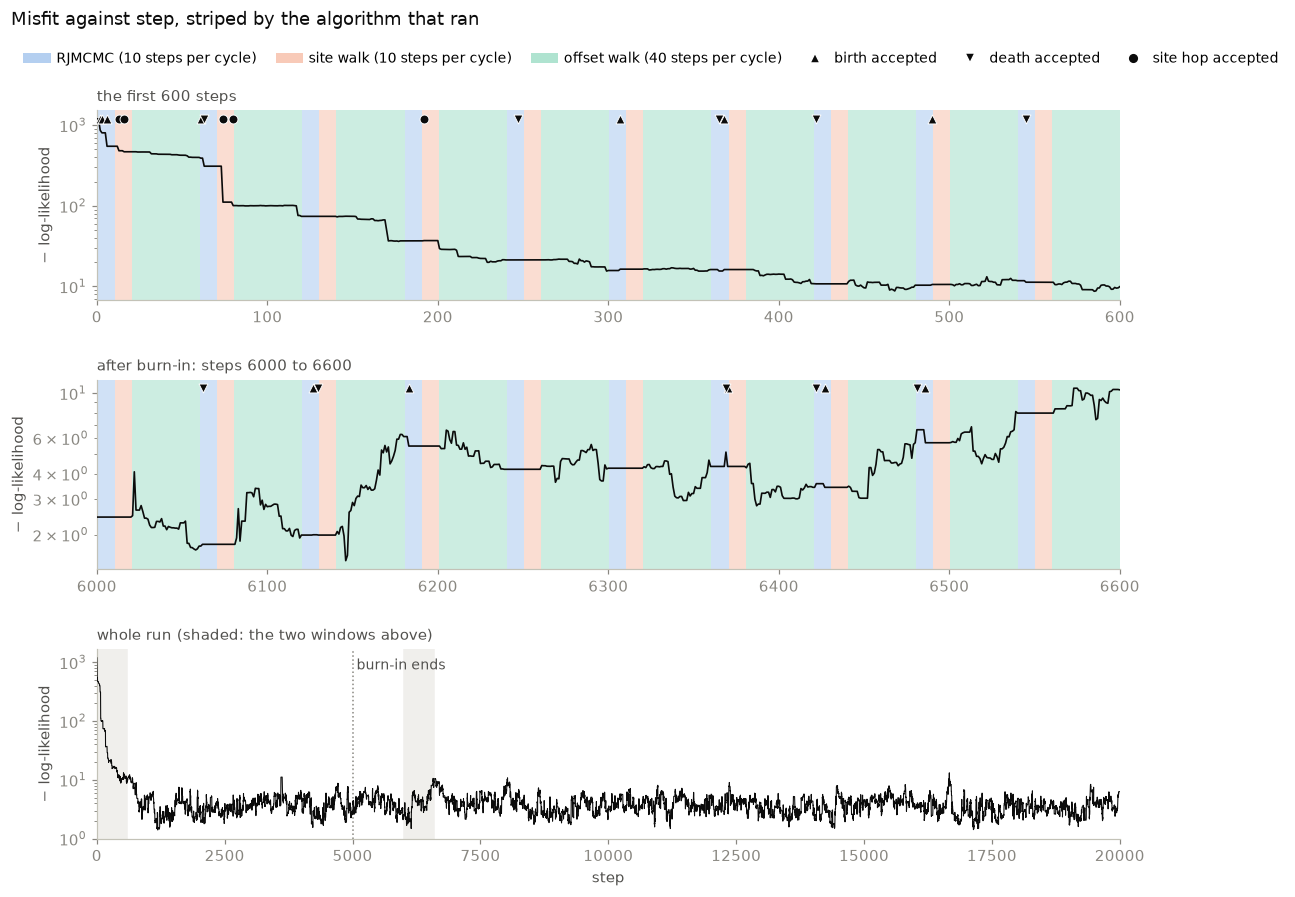

In [5]:
WINDOW = 600


def _stripes(ax, res, first, last):
    """Shade each contiguous run of one algorithm between two steps."""
    labels = res["algorithm"][first:last]            # steps first+1 .. last
    edges = np.flatnonzero(labels[1:] != labels[:-1]) + 1
    starts = np.concatenate([[0], edges])
    stops = np.concatenate([edges, [len(labels)]])
    for a, b in zip(starts, stops, strict=True):
        ax.axvspan(first + a + 0.5, first + b + 0.5,
                   color=ALGORITHM_COLOURS[labels[a]], alpha=0.22, lw=0,
                   zorder=0)


def _moves(ax, res, first, last):
    """Accepted configuration changes, along the top edge of the panel."""
    for key, marker in (("births", "^"), ("deaths", "v"), ("hops", "o")):
        at = res[key][(res[key] > first) & (res[key] <= last)]
        ax.scatter(at, np.full(at.size, 0.955), marker=marker, s=34,
                   color=C_INK, edgecolor="white", linewidths=0.6, zorder=4,
                   transform=ax.get_xaxis_transform(), clip_on=False)


def plot_algorithms(res):
    steps = np.arange(len(res["k"]))
    misfit = -res["log_like"]
    windows = [(0, WINDOW), (N_BURN + 1000, N_BURN + 1000 + WINDOW)]
    fig, axes = plt.subplots(3, 1, figsize=(12.0, 8.6),
                             gridspec_kw={"hspace": 0.42})
    for ax, (first, last), name in zip(
            axes[:2], windows, ("the first", "after burn-in:"), strict=True):
        _stripes(ax, res, first, last)
        _moves(ax, res, first, last)
        show = slice(first, last + 1)
        ax.plot(steps[show], misfit[show], color=C_INK, lw=1.1, zorder=3)
        ax.set_xlim(first, last)
        ax.set_yscale("log")
        ax.set_ylabel("− log-likelihood")
        ax.set_title(f"{name} {WINDOW} steps" if first == 0 else
                     f"{name} steps {first} to {last}",
                     loc="left", color="#52514e", fontsize=10)
    whole = axes[2]
    whole.plot(steps, misfit, color=C_INK, lw=0.7, zorder=3)
    for first, last in windows:
        whole.axvspan(first, last, color=C_SOFT, zorder=0)
    whole.axvline(N_BURN, color=C_MUTED, lw=1.0, ls=":", zorder=1)
    whole.text(N_BURN, 0.95, " burn-in ends", fontsize=9, color="#52514e",
               va="top", transform=whole.get_xaxis_transform())
    whole.set_xlim(0, len(steps) - 1)
    whole.set_yscale("log")
    whole.set_ylabel("− log-likelihood")
    whole.set_xlabel("step")
    whole.set_title("whole run (shaded: the two windows above)", loc="left",
                    color="#52514e", fontsize=10)

    handles = [Patch(facecolor=colour, alpha=0.35,
                     label=f"{name} ({BLOCKS[name]} steps per cycle)")
               for name, colour in ALGORITHM_COLOURS.items()]
    for marker, name in (("^", "birth accepted"), ("v", "death accepted"),
                         ("o", "site hop accepted")):
        handles.append(plt.Line2D([], [], marker=marker, ls="", color=C_INK,
                                  markeredgecolor="white", ms=7, label=name))
    fig.legend(handles=handles, loc="upper left", ncols=6, fontsize=9,
               bbox_to_anchor=(0.06, 0.955), handletextpad=0.4,
               columnspacing=1.4)
    fig.suptitle("Misfit against step, striped by the algorithm that ran",
                 x=0.06, y=0.985, ha="left", color=C_INK)
    plt.show()


plot_algorithms(main)

## 5. Sites and spin count against step

Top: a row per site, filled where the site is occupied. Bottom: the number
of spins. The opening steps are shown beside the whole run.

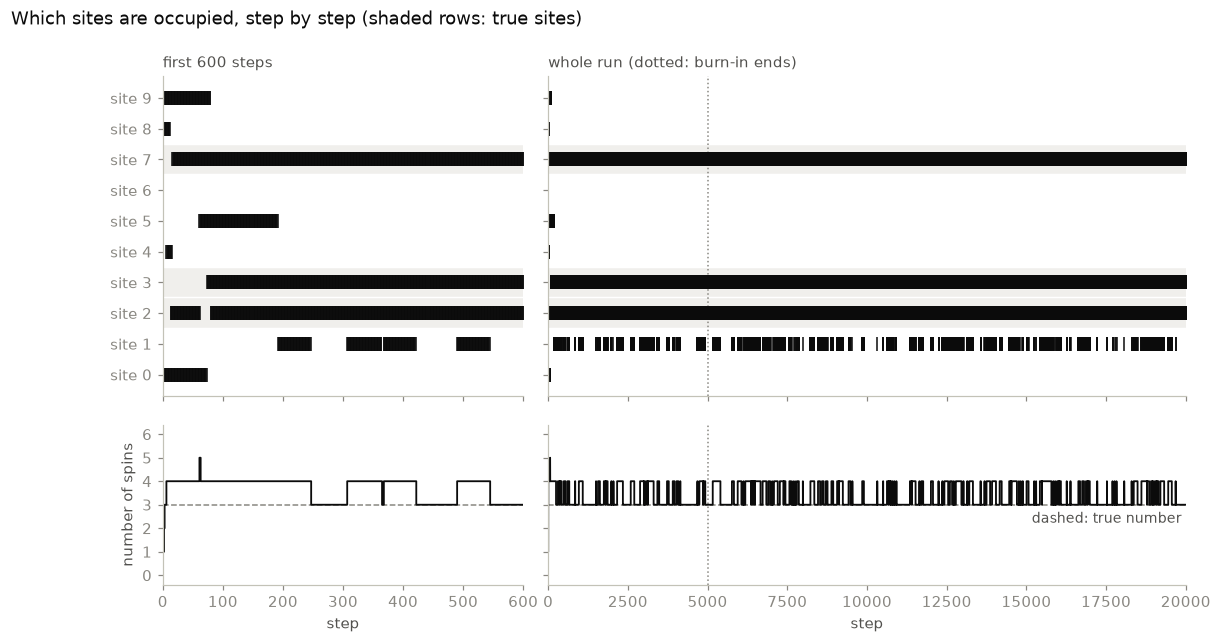

In [6]:
def plot_sites_and_count(res, opening=WINDOW):
    steps = np.arange(len(res["k"]))
    fig, axes = plt.subplots(
        2, 2, figsize=(12.0, 6.0), sharex="col", sharey="row",
        gridspec_kw={"width_ratios": [1.3, 2.3], "height_ratios": [2.0, 1],
                     "hspace": 0.12, "wspace": 0.05})
    for column, last in enumerate((opening, len(steps) - 1)):
        top, bottom = axes[0, column], axes[1, column]
        for s in TRUE_SITES:
            top.axhspan(s - 0.45, s + 0.45, color=C_SOFT, zorder=0)
        for i in range(N_SITES):
            on = np.flatnonzero(res["occupancy"][: last + 1, i])
            top.scatter(on, np.full(on.size, i), marker="|", s=90,
                        linewidths=1.0, color=C_INK, zorder=2)
        bottom.axhline(len(TRUE_SITES), color=C_MUTED, lw=1.0, ls="--",
                       zorder=1)
        bottom.plot(steps[: last + 1], res["k"][: last + 1],
                    drawstyle="steps-post", color=C_INK, lw=1.2, zorder=2)
        bottom.set_xlabel("step")
        if last > N_BURN:
            for ax in (top, bottom):
                ax.axvline(N_BURN, color=C_MUTED, lw=1.0, ls=":", zorder=1)
        for ax in (top, bottom):
            ax.set_xlim(0, last)
        top.set_title(f"first {opening} steps" if column == 0 else
                      "whole run (dotted: burn-in ends)",
                      loc="left", color="#52514e", fontsize=10)
    axes[0, 0].set_yticks(range(N_SITES), [f"site {i}" for i in range(N_SITES)])
    axes[0, 0].set_ylim(-0.7, N_SITES - 0.3)
    axes[1, 0].set_yticks(range(K_MAX + 1))
    axes[1, 0].set_ylim(-0.4, K_MAX + 0.4)
    axes[1, 0].set_ylabel("number of spins")
    axes[1, 1].text(len(steps) - 1, len(TRUE_SITES) - 0.3,
                    "dashed: true number ", ha="right", va="top", fontsize=9,
                    color="#52514e")
    fig.suptitle("Which sites are occupied, step by step "
                 "(shaded rows: true sites)", x=0.01, ha="left", color=C_INK)
    plt.show()


plot_sites_and_count(main)

## 6. What the posterior says

Left: how often each site is occupied after burn-in. Right: how often the
configuration has each number of spins.

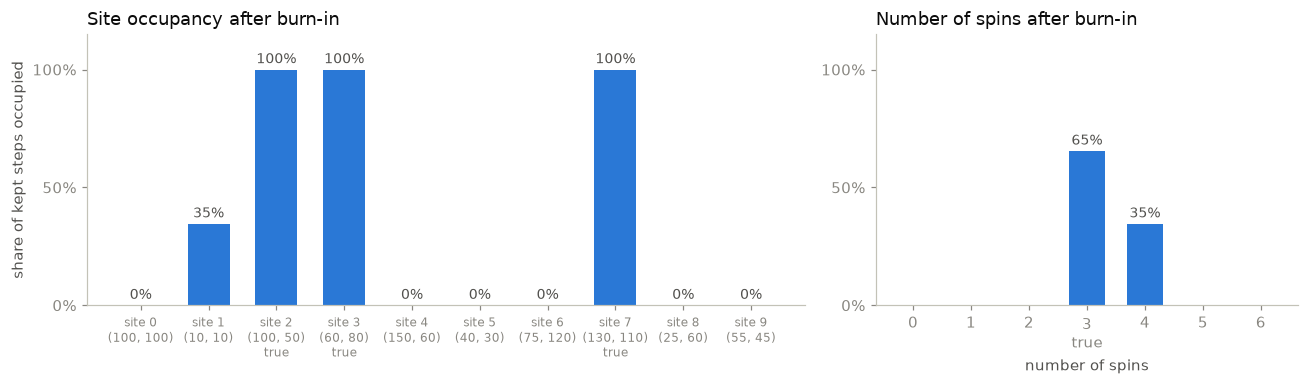

In [7]:
def plot_posterior(res):
    kept_occ = res["occupancy"][N_BURN:].mean(axis=0)
    k_share = np.bincount(res["k"][N_BURN:], minlength=K_MAX + 1) / len(
        res["k"][N_BURN:])
    fig, (left, right) = plt.subplots(
        1, 2, figsize=(12.0, 3.6), gridspec_kw={"width_ratios": [1.7, 1]})

    bars = left.bar(range(N_SITES), kept_occ, width=0.62, color=C_SAMPLE)
    left.bar_label(bars, labels=[f"{v:.0%}" for v in kept_occ], fontsize=9,
                   color="#52514e", padding=2)
    left.set_xticks(range(N_SITES), [
        f"site {i}\n({CENTRES[i, 0]:.0f}, {CENTRES[i, 1]:.0f})"
        + ("\ntrue" if i in TRUE else "") for i in range(N_SITES)], fontsize=8)
    left.set_ylim(0, 1.15)
    left.set_yticks([0, 0.5, 1.0], ["0%", "50%", "100%"])
    left.set_ylabel("share of kept steps occupied")
    left.set_title("Site occupancy after burn-in", loc="left", color=C_INK)

    bars = right.bar(range(K_MAX + 1), k_share, width=0.62, color=C_SAMPLE)
    right.bar_label(bars, labels=[f"{v:.0%}" if v > 0 else "" for v in k_share],
                    fontsize=9, color="#52514e", padding=2)
    right.set_xticks(range(K_MAX + 1), [
        f"{n}\ntrue" if n == len(TRUE_SITES) else str(n)
        for n in range(K_MAX + 1)])
    right.set_ylim(0, 1.15)
    right.set_yticks([0, 0.5, 1.0], ["0%", "50%", "100%"])
    right.set_xlabel("number of spins")
    right.set_title("Number of spins after burn-in", loc="left", color=C_INK)
    fig.tight_layout()
    plt.show()


plot_posterior(main)

The three true sites are occupied at every kept step, and their couplings
are recovered. The walk gets there quickly: all three are occupied within
the first hundred steps, and stay occupied.

The number of spins is not settled, and should not be. Site 1 is occupied
about a third of the time, so the count sits at three for 65% of kept steps
and at four for 35%. Site 1 is the weakest site on the lattice, (10, 10)
kHz, and a spin there barely changes the signal. With a prior that is
uniform in the number of spins, a spin with no effect at all would be
present half the time. A third says the data argue against it only mildly.
The births and deaths that continue through the whole run, 127 and 125 of
them, are almost all this one spin appearing and disappearing.

## 7. The walk in coupling space, and within each site

Every site's rectangle to scale, then one panel per site with the offset as
a percentage of the table value, so that every rectangle is the same ±10%
square. Grey points are from burn-in.

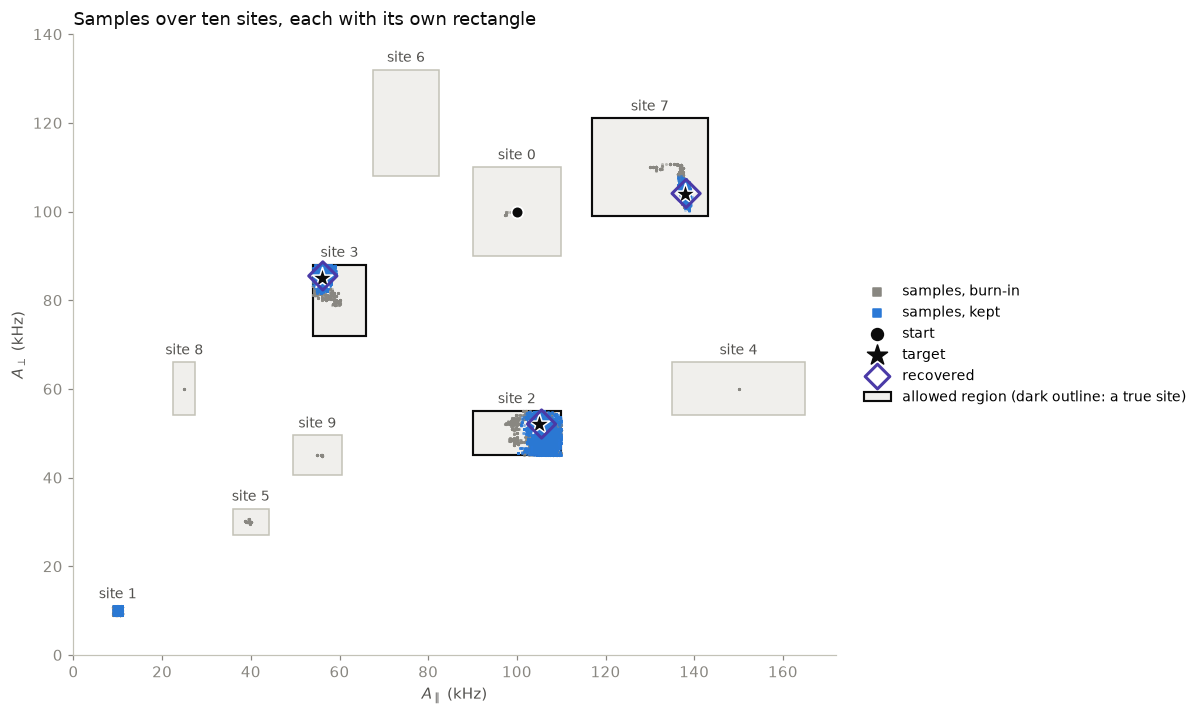

In [8]:
def _site_markers(ax, res, i, relative=False):
    """Start, target and recovered markers for site ``i``, if it has them."""
    def place(point):
        if not relative:
            return point
        return 100.0 * (np.asarray(point) - CENTRES[i]) / CENTRES[i]

    best = res["best"]
    if i in START_SITES:
        ax.scatter(*place(CENTRES[i]), s=60, marker="o", color=C_INK,
                   edgecolor="white", linewidths=1.2, zorder=6)
    if i in TRUE:
        ax.scatter(*place(CENTRES[i] + np.array(TRUE[i])), s=210, marker="*",
                   color=C_INK, edgecolor="white", linewidths=1.0, zorder=7)
    for slot in np.flatnonzero(res["site"][best] == i):
        ax.scatter(*place((res["a_par"][best, slot], res["a_perp"][best, slot])),
                   s=170, marker="D", facecolor="none", edgecolor=C_RECOVERED,
                   linewidths=2.0, zorder=8)


def plot_coupling_space(res):
    kept = np.arange(len(res["k"])) >= N_BURN
    fig, ax = plt.subplots(figsize=(11.0, 6.6))
    for i in range(N_SITES):
        is_true = i in TRUE
        ax.add_patch(Rectangle(
            CENTRES[i] - HALF[i], 2 * HALF[i, 0], 2 * HALF[i, 1],
            facecolor=C_SOFT, edgecolor=C_INK if is_true else C_AXIS,
            lw=1.4 if is_true else 1.0, zorder=0))
        ax.annotate(f"site {i}", (CENTRES[i, 0], CENTRES[i, 1] + HALF[i, 1]),
                    xytext=(0, 3), textcoords="offset points", ha="center",
                    va="bottom", fontsize=9, color="#52514e")
        _site_markers(ax, res, i)
    ax.scatter(res["a_par"][~kept], res["a_perp"][~kept], s=4, color=C_MUTED,
               alpha=0.5, linewidths=0, zorder=2)
    ax.scatter(res["a_par"][kept], res["a_perp"][kept], s=4, color=C_SAMPLE,
               alpha=0.3, linewidths=0, zorder=3)

    ax.scatter([], [], s=30, marker="s", color=C_MUTED, label="samples, burn-in")
    ax.scatter([], [], s=30, marker="s", color=C_SAMPLE, label="samples, kept")
    ax.scatter([], [], s=60, marker="o", color=C_INK, label="start")
    ax.scatter([], [], s=190, marker="*", color=C_INK, label="target")
    ax.scatter([], [], s=130, marker="D", facecolor="none",
               edgecolor=C_RECOVERED, linewidths=2.0, label="recovered")
    ax.add_patch(Rectangle((0, 0), 0, 0, facecolor=C_SOFT, edgecolor=C_INK,
                           lw=1.4,
                           label="allowed region (dark outline: a true site)"))
    ax.set_aspect("equal")
    ax.set_xlim(0, 172)
    ax.set_ylim(0, 140)
    ax.set_xlabel(r"$A_\parallel$ (kHz)")
    ax.set_ylabel(r"$A_\perp$ (kHz)")
    ax.set_title("Samples over ten sites, each with its own rectangle",
                 loc="left", color=C_INK)
    ax.legend(loc="center left", bbox_to_anchor=(1.02, 0.5), fontsize=9)
    fig.tight_layout()
    plt.show()


def plot_within_sites(res):
    kept = np.arange(len(res["k"])) >= N_BURN
    kept_occ = res["occupancy"][N_BURN:].mean(axis=0)
    fig, axes = plt.subplots(2, 5, figsize=(13.5, 6.0), sharex=True,
                             sharey=True, layout="constrained")
    for i, ax in enumerate(axes.flat):
        ax.add_patch(Rectangle((-10, -10), 20, 20, facecolor=C_SOFT,
                               edgecolor=C_INK if i in TRUE else C_AXIS,
                               lw=1.4 if i in TRUE else 1.0, zorder=0))
        ax.axhline(0.0, color=C_AXIS, lw=0.8, zorder=1)
        ax.axvline(0.0, color=C_AXIS, lw=0.8, zorder=1)
        here = res["site"] == i
        x = 100.0 * res["d_par"] / CENTRES[i, 0]
        y = 100.0 * res["d_perp"] / CENTRES[i, 1]
        early, late = here & ~kept[:, None], here & kept[:, None]
        ax.scatter(x[early], y[early], s=5, color=C_MUTED, alpha=0.5,
                   linewidths=0, zorder=2)
        ax.scatter(x[late], y[late], s=5, color=C_SAMPLE, alpha=0.3,
                   linewidths=0, zorder=3)
        _site_markers(ax, res, i, relative=True)
        ax.set_xlim(-11.5, 11.5)
        ax.set_ylim(-11.5, 11.5)
        ax.set_aspect("equal")
        ax.set_title(f"site {i} ({CENTRES[i, 0]:.0f}, {CENTRES[i, 1]:.0f})\n"
                     f"±{HALF[i, 0]:.1f} × ±{HALF[i, 1]:.1f} kHz, "
                     f"occupied {kept_occ[i]:.0%}",
                     loc="left", color=C_INK, fontsize=9)
    for ax in axes[1]:
        ax.set_xlabel(r"$\delta_\parallel$ (% of $A_\parallel$)")
    for ax in axes[:, 0]:
        ax.set_ylabel(r"$\delta_\perp$ (% of $A_\perp$)")
    fig.suptitle("Within sites: each site's offset, as a percentage of its "
                 "table value (dark outline: a true site)", x=0.01, ha="left",
                 color=C_INK)
    plt.show()


plot_coupling_space(main)

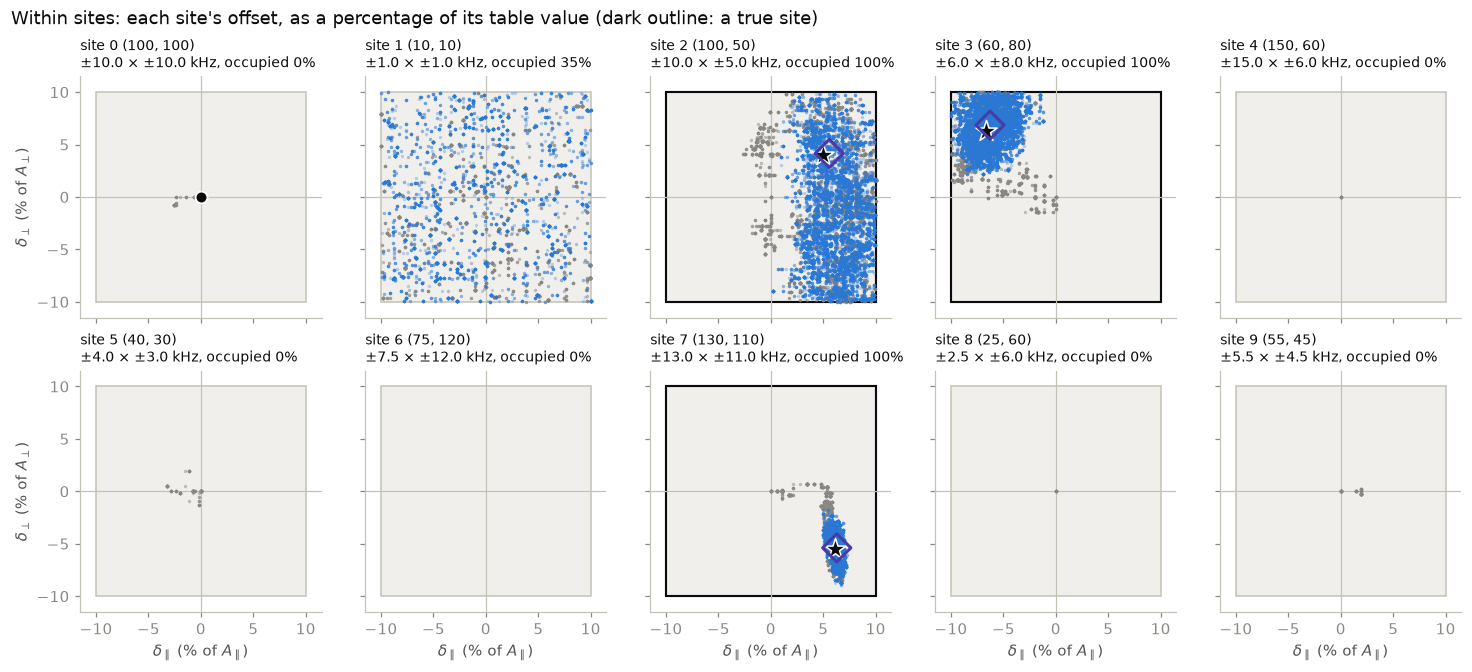

In [9]:
plot_within_sites(main)

## 8. The signals

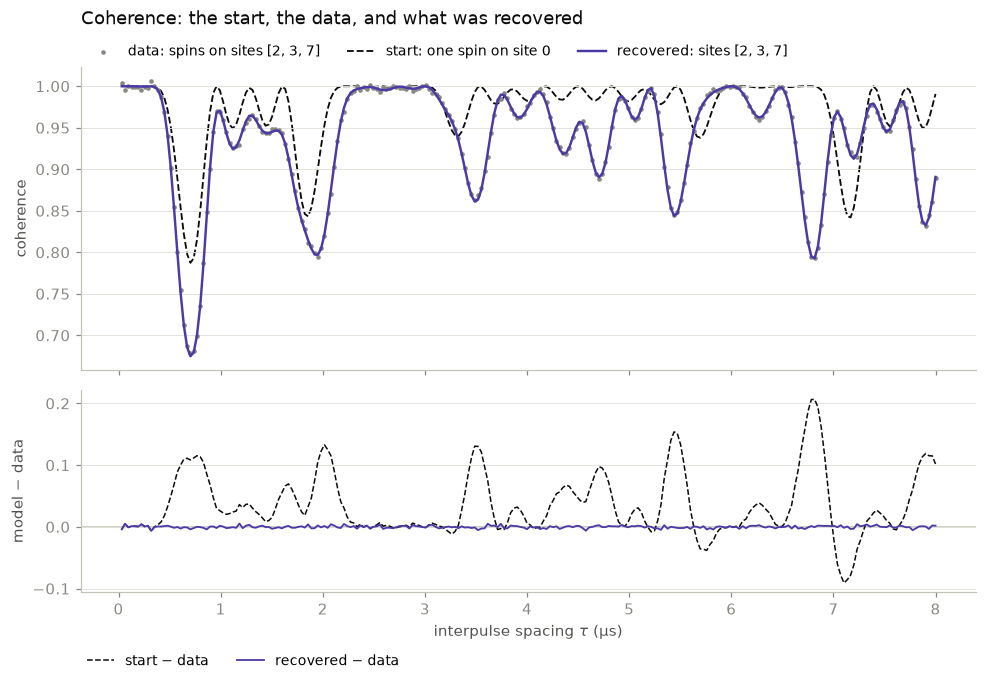

rms residual, recovered: 0.0021   (data noise 0.002)


In [10]:
def plot_signals(res):
    sig_initial = simulate_coherence(res["initial"], blank, table, model)
    sig_recovered = simulate_coherence(res["recovered"], blank, table, model)
    measured = data.data_all
    tau_us = tau * 1e3
    _, (top, bottom) = plt.subplots(
        2, 1, figsize=(10.5, 6.2), sharex=True,
        gridspec_kw={"height_ratios": [3, 2], "hspace": 0.08})
    top.scatter(tau_us, measured, s=9, color=C_MUTED, linewidths=0, zorder=2,
                label=f"data: spins on sites {list(TRUE_SITES)}")
    top.plot(tau_us, sig_initial, color=C_INK, lw=1.2, ls="--", zorder=1,
             label=f"start: one spin on site {START_SITES[0]}")
    top.plot(tau_us, sig_recovered, color=C_RECOVERED, lw=1.6, zorder=3,
             label=f"recovered: sites {[int(s) for s in res['modal']]}")
    top.set_ylabel("coherence")
    top.set_title("Coherence: the start, the data, and what was recovered",
                  loc="left", color=C_INK, pad=28)
    top.legend(loc="lower left", bbox_to_anchor=(0.0, 1.0), ncols=3,
               fontsize=9, borderaxespad=0.2)
    top.grid(axis="y")

    bottom.axhline(0.0, color=C_AXIS, lw=1.0, zorder=1)
    bottom.plot(tau_us, sig_initial - measured, color=C_INK, lw=1.0, ls="--",
                zorder=2, label="start − data")
    bottom.plot(tau_us, sig_recovered - measured, color=C_RECOVERED, lw=1.2,
                zorder=3, label="recovered − data")
    bottom.set_xlabel(r"interpulse spacing $\tau$ (µs)")
    bottom.set_ylabel("model − data")
    bottom.legend(loc="upper left", bbox_to_anchor=(0.0, -0.28), ncols=2,
                  fontsize=9, borderaxespad=0.0)
    bottom.grid(axis="y")
    plt.show()
    rms = np.sqrt(np.mean((sig_recovered - measured) ** 2))
    print(f"rms residual, recovered: {rms:.4f}   (data noise {DATA_NOISE})")


plot_signals(main)

## 9. A second seed

The same data and the same schedule, with a different random seed.

In [11]:
other = run_walk(seed=0)
report(other)

accepted moves: 112 births, 108 deaths, 7 site hops
log-likelihood: start -1198.7, truth -1.29

most visited sets of sites after burn-in:
  [2, 3, 7, 9]         63%
  [1, 2, 3, 7, 9]      37%

recovered: sites [2, 3, 7, 9], log-likelihood -1.58
site      target (kHz)     recovered (kHz)
   2  (105.00,  52.00)  ( 106.07,   51.32)
   3  ( 56.00,  85.00)  (  59.69,   74.45)
   7  (138.00, 104.00)  ( 137.93,  104.04)
   9   not a true site  (  58.88,   44.82)


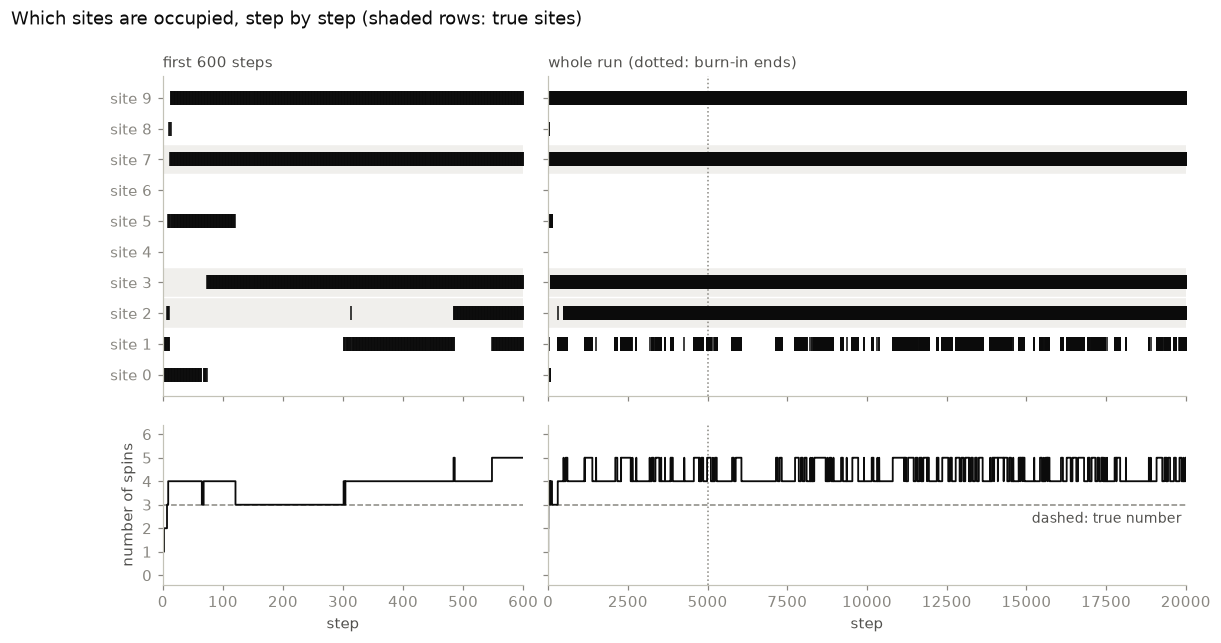

In [12]:
plot_sites_and_count(other)

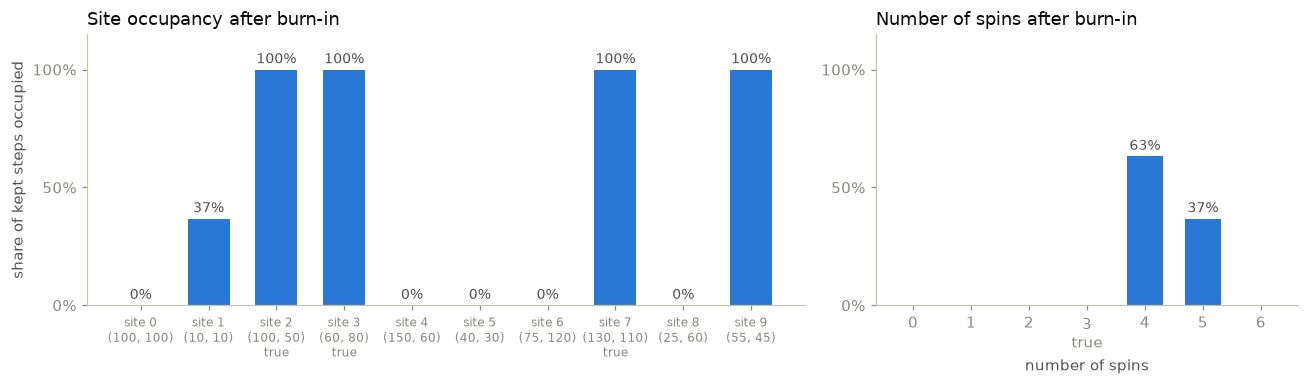

In [13]:
plot_posterior(other)

This run does not agree with the first. It holds a fourth spin on site 9
for every kept step, and never visits the true set of three at all.

It is a different explanation of the same data, not a failed fit. With a
spin on site 9 at about (59, 45) kHz, site 3 settles near (60, 74), more
than 10 kHz from its true perpendicular coupling, and between them the two
spins reproduce what the single true spin on site 3 does. The best
log-likelihood on this set is −1.58, against −1.42 on the true set in the
first run: the data barely prefer one to the other.

What the two runs show together is that a single chain does not move
between these two explanations. Removing the spin on site 9 would need
site 3 to be back at its true coupling first, and site 3 only moves there
once site 9 is gone. Of seeds 0 to 3, two ended on each. So the posterior
over the number of spins cannot be read off one run: each chain reports its
own mode with confidence. This is the problem that running several chains
and comparing them, or tempering, exists to deal with.